In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
pd.set_option('display.max_columns', None)
data = pd.read_csv('/content/drive/MyDrive/MLProject/notebook/credit_risk_dataset_cleaned.csv')
data.head()

,age,gender,employment_status,annual_income,account_age_months,avg_monthly_balance,num_deposits_per_month,avg_deposit_amount,debit_card_usage_frequency,debit_card_spending,mobile_banking_logins,online_transfer_frequency,atm_withdrawal_frequency,credit_score,num_open_loans,total_outstanding_debt,late_payment_count,loan_default_history,fraud_flag,loan_application_amount,credit_risk
0,58,Male,Unemployed,58137.75,115,524.68,1,171.34,49,768.88,9,16,1,539,5,14435.42,2,0,0,15510.58,1
1,48,Male,Self-Employed,26174.92,32,2635.20,1,985.61,1,580.29,9,1,2,494,5,11263.10,2,0,0,14819.44,1
2,34,Other,Unemployed,75566.84,14,2334.34,9,994.31,42,564.01,36,5,6,437,3,15017.14,5,0,0,10909.81,1
3,62,Male,Self-Employed,35197.96,179,2425.38,10,366.12,4,838.49,31,7,7,809,1,12626.14,2,0,0,500.00,0
4,27,Female,Self-Employed,12137.00,225,10.00,8,786.75,16,462.50,35,16,3,522,1,13576.70,4,0,0,9514.59,1


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         5000 non-null   int64  
 1   gender                      5000 non-null   object 
 2   employment_status           5000 non-null   object 
 3   annual_income               5000 non-null   float64
 4   account_age_months          5000 non-null   int64  
 5   avg_monthly_balance         5000 non-null   float64
 6   num_deposits_per_month      5000 non-null   int64  
 7   avg_deposit_amount          5000 non-null   float64
 8   debit_card_usage_frequency  5000 non-null   int64  
 9   debit_card_spending         5000 non-null   float64
 10  mobile_banking_logins       5000 non-null   int64  
 11  online_transfer_frequency   5000 non-null   int64  
 12  atm_withdrawal_frequency    5000 non-null   int64  
 13  credit_score                5000 

In [5]:
cat_cols = data.select_dtypes(include='object').columns
cat_cols

Index(['gender', 'employment_status'], dtype='object')

In [6]:
binary_cols = [col for col in data if data[col].nunique() == 2]
binary_cols

['loan_default_history', 'fraud_flag', 'credit_risk']

In [7]:
data[binary_cols] = data[binary_cols].astype('O')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         5000 non-null   int64  
 1   gender                      5000 non-null   object 
 2   employment_status           5000 non-null   object 
 3   annual_income               5000 non-null   float64
 4   account_age_months          5000 non-null   int64  
 5   avg_monthly_balance         5000 non-null   float64
 6   num_deposits_per_month      5000 non-null   int64  
 7   avg_deposit_amount          5000 non-null   float64
 8   debit_card_usage_frequency  5000 non-null   int64  
 9   debit_card_spending         5000 non-null   float64
 10  mobile_banking_logins       5000 non-null   int64  
 11  online_transfer_frequency   5000 non-null   int64  
 12  atm_withdrawal_frequency    5000 non-null   int64  
 13  credit_score                5000 

In [8]:
cat_cols = data.select_dtypes(include='object').columns
cat_cols

Index(['gender', 'employment_status', 'loan_default_history', 'fraud_flag',
       'credit_risk'],
      dtype='object')

In [9]:
for col in cat_cols:
    print(f'\nUnique values in {col} are: \n', data[col].value_counts())


Unique values in gender are: 
 gender
Female    1705
Other     1680
Male      1615
Name: count, dtype: int64

Unique values in employment_status are: 
 employment_status
Employed         1746
Self-Employed    1633
Unemployed       1621
Name: count, dtype: int64

Unique values in loan_default_history are: 
 loan_default_history
0    4513
1     487
Name: count, dtype: int64

Unique values in fraud_flag are: 
 fraud_flag
0    4857
1     143
Name: count, dtype: int64

Unique values in credit_risk are: 
 credit_risk
1    3829
0    1171
Name: count, dtype: int64


In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

## Segregating X and y  

In [11]:
X = data.drop(columns = ['credit_risk'], axis = 1)
y = data['credit_risk']

In [12]:
print(X.shape, y.shape)

(5000, 20) (5000,)


In [13]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size = 0.2,
                                                    random_state = 42,
                                                    stratify=y)

- stratify=y for imbalanced classification problems — ensures both train and test sets proportionally represent all classes!

In [14]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(4000, 20) (1000, 20) (4000,) (1000,)


In [15]:
# Using column transformer

# Defining column groups
cat_cols = ['gender', 'employment_status']
num_cols = X.select_dtypes(include='number').columns.to_list()
binary_cols = [col for col in X.columns if X[col].nunique() == 2]

# # Removing binary cols from num_cols to avoid overlap!
# num_cols = [col for col in num_cols if col not in binary_cols]

# Defining Transformers
OH_Encoder = OneHotEncoder(drop='first', sparse_output=False)
Std_Scaler = StandardScaler()

# ColumnTransformer
ct = ColumnTransformer(
    [
        ('OneHotEncoder', OH_Encoder, cat_cols),
        ('StandardScaler', Std_Scaler, num_cols),
        ('binary', 'passthrough', binary_cols)
    ]
)

# Fit on train, transform both
X_train = ct.fit_transform(X_train)
X_test = ct.transform(X_test)


In [16]:
type(X_train)

numpy.ndarray

In [17]:
type(X_test)

numpy.ndarray

In [18]:
# After ColumnTransformer — X_train becomes a NumPy array
# We lose column names!

In [19]:
# to retain column names for interpretability:

ohe_cols = ct.named_transformers_['OneHotEncoder'].get_feature_names_out(cat_cols)
final_cols = list(ohe_cols) + num_cols + binary_cols

X_train = pd.DataFrame(X_train, columns=final_cols)
X_test  = pd.DataFrame(X_test, columns=final_cols)

In [20]:
X_train.shape, X_test.shape

((4000, 22), (1000, 22))

In [21]:
X_train.head()

,gender_Male,gender_Other,employment_status_Self-Employed,employment_status_Unemployed,age,annual_income,account_age_months,avg_monthly_balance,num_deposits_per_month,avg_deposit_amount,debit_card_usage_frequency,debit_card_spending,mobile_banking_logins,online_transfer_frequency,atm_withdrawal_frequency,credit_score,num_open_loans,total_outstanding_debt,late_payment_count,loan_application_amount,loan_default_history,fraud_flag
0,0.0,1.0,0.0,0.0,0.589145,-0.103571,-1.207062,2.079105,1.001976,-0.438264,-1.021343,0.092337,-1.563033,1.608778,-0.543583,1.306009,1.493325,0.173902,-0.208388,1.552961,1,0
1,1.0,0.0,0.0,0.0,-1.087341,1.223576,1.529708,0.655206,1.001976,0.420471,0.231134,1.802974,1.470215,1.09602,0.492471,1.168006,0.901441,-0.937007,1.535444,1.770669,0,0
2,0.0,1.0,0.0,0.0,0.868559,-0.043592,-0.48994,-1.208427,1.58524,-1.406504,-1.160507,0.613745,0.776901,0.070504,-1.234285,1.553265,-0.282329,0.173881,1.535444,1.748247,1,0
3,0.0,0.0,0.0,1.0,0.658999,-1.888127,1.676059,-0.01954,-0.747818,-0.341361,-1.369253,-0.796764,0.386912,-0.442254,1.528524,-1.10905,-0.874214,1.138794,-0.208388,1.327796,0,0
4,0.0,1.0,1.0,0.0,0.10017,-0.633912,-1.119251,0.063148,0.710343,0.499157,1.066119,-0.724276,1.123558,0.754182,1.528524,-1.626562,0.901441,0.41881,1.099486,0.281978,0,0


In [22]:
X_test.head()

,gender_Male,gender_Other,employment_status_Self-Employed,employment_status_Unemployed,age,annual_income,account_age_months,avg_monthly_balance,num_deposits_per_month,avg_deposit_amount,debit_card_usage_frequency,debit_card_spending,mobile_banking_logins,online_transfer_frequency,atm_withdrawal_frequency,credit_score,num_open_loans,total_outstanding_debt,late_payment_count,loan_application_amount,loan_default_history,fraud_flag
0,1.0,0.0,0.0,1.0,0.589145,-0.352854,-0.050886,0.316405,1.001976,-0.699849,0.022388,-0.593083,0.040256,1.26694,0.837822,-0.367282,1.493325,-0.604232,-1.080304,1.109344,0,1
1,0.0,0.0,0.0,1.0,-1.646169,1.168418,-0.226508,0.194823,0.418711,1.07958,-1.160507,0.191368,1.686876,-0.784092,-1.579636,-1.241303,1.493325,0.744013,-1.516262,0.484475,0,1
2,0.0,1.0,1.0,0.0,1.287681,-0.847538,-1.294872,-1.229038,1.293608,-1.796163,1.692357,-0.958397,0.646905,0.925101,-1.579636,1.472763,-0.282329,0.356038,-1.080304,-0.391417,1,0
3,0.0,1.0,1.0,0.0,-0.039537,1.224185,-1.397318,1.667415,-1.622715,-1.218809,-0.116776,-0.544839,-1.30304,1.09602,-1.234285,-0.597287,-0.874214,-0.375684,-1.080304,0.476987,0,0
4,0.0,1.0,0.0,0.0,1.287681,0.030195,-1.148521,-0.40792,0.418711,-0.678007,-0.395104,0.968024,-0.436398,-1.46777,0.14712,-0.137276,0.309556,0.567751,0.663528,-0.598306,0,0


# Model Training


In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [24]:
y_train = y_train.astype(int)
y_test  = y_test.astype(int)

# Verify
print(y_train.dtype)
print(y_train.unique())

int64
[1 0]


In [25]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(class_weight = 'balanced')

log_reg.fit(X_train, y_train)

y_pred_train = log_reg.predict(X_train)
y_pred_test = log_reg.predict(X_test)

print('Train Performance: ')
print(confusion_matrix(y_train, y_pred_train))
print(classification_report(y_train, y_pred_train))

print('-'*40)

print('Test Performace: ')
print(confusion_matrix(y_test, y_pred_test))
print(classification_report(y_test, y_pred_test))

Train Performance: 
[[ 862   75]
 [ 307 2756]]
              precision    recall  f1-score   support

           0       0.74      0.92      0.82       937
           1       0.97      0.90      0.94      3063

    accuracy                           0.90      4000
   macro avg       0.86      0.91      0.88      4000
weighted avg       0.92      0.90      0.91      4000

----------------------------------------
Test Performace: 
[[202  32]
 [ 89 677]]
              precision    recall  f1-score   support

           0       0.69      0.86      0.77       234
           1       0.95      0.88      0.92       766

    accuracy                           0.88      1000
   macro avg       0.82      0.87      0.84      1000
weighted avg       0.89      0.88      0.88      1000



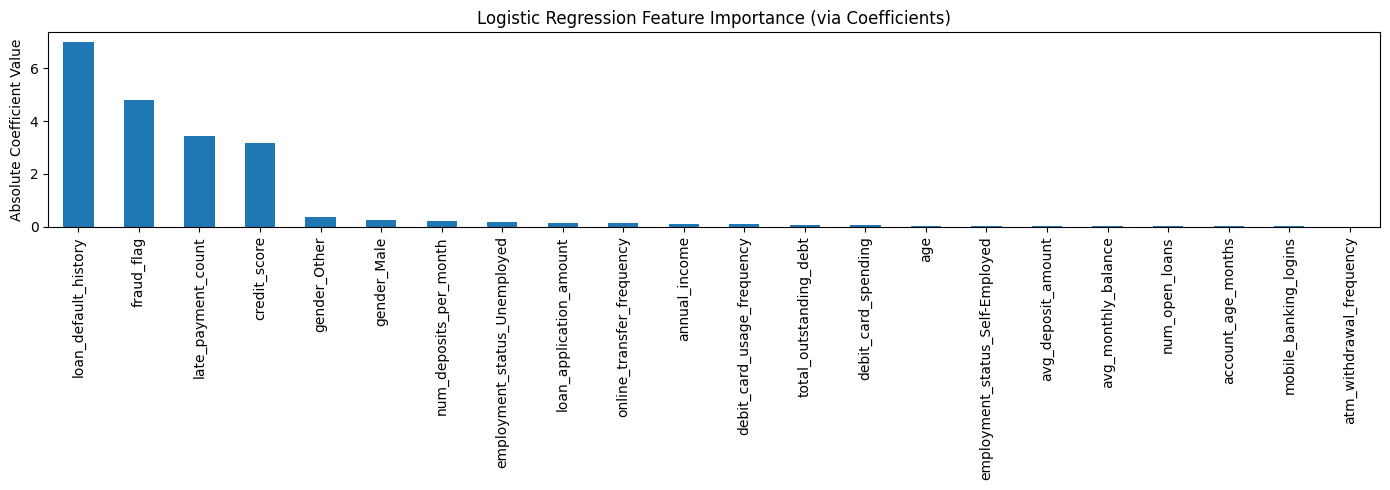

In [26]:
# Logistic Regression Feature Importance

# Extract coefficients
coefficients = pd.Series(log_reg.coef_[0], index=X_train.columns)

# Sort by absolute value — direction doesn't matter for importance
coefficients_abs = coefficients.abs().sort_values(ascending=False)

# Plot
coefficients_abs.plot(kind='bar', figsize=(14, 5))
plt.title('Logistic Regression Feature Importance (via Coefficients)')
plt.ylabel('Absolute Coefficient Value')
plt.tight_layout()
plt.show()

In [27]:
# as log reg is picking very few features for it's training, and wanna keep all features for business perspective
# so, let's check if irrelevant columns are adding any noise to the model...


In [28]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(log_reg, X_train, y_train, cv = 5, scoring = 'f1')
print(f'CV F1 Scores:, {scores}')
print(f'Mean: {scores.mean():.3f} ± {scores.std():.3f}')

CV F1 Scores:, [0.92620865 0.93074324 0.9364945  0.92399658 0.93606138]
Mean: 0.931 ± 0.005


±0.005 std is exceptionally low — means the model performs almost identically across every data split. Zero instability!

In [29]:
# Comparing Full vs Reduced Feature Set

# Training with only top features

top_features = ['loan_default_history', 'fraud_flag',
                'late_payment_count', 'credit_score']

lr_reduced = LogisticRegression(class_weight='balanced')
lr_reduced.fit(X_train[top_features], y_train)

scores_full = cross_val_score(log_reg, X_train, y_train, cv = 5, scoring = 'f1').mean()
scores_reduced = cross_val_score(lr_reduced, X_train[top_features], y_train, cv = 5, scoring = 'f1').mean()

print(f'Full features F1 : {scores_full:.3f}')
print(f'Reduced features F1 : {scores_reduced:.3f}')

Full features F1 : 0.931
Reduced features F1 : 0.931


This is the most conclusive evidence — removing 18+ features made absolutely zero difference to performance.
Which means:

- Low importance features
  - → Adding ZERO noise
  - → Adding ZERO value to predictions
  - → But adding 100% business value

In [30]:
# Decision Tree

from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(class_weight = 'balanced',
                               criterion = 'gini',
                               max_depth = 2
                               )

model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print('Train Performance: ')
print(confusion_matrix(y_train, y_pred_train))
print(classification_report(y_train, y_pred_train))

print('-'*40)
print(confusion_matrix(y_test, y_pred_test))
print(classification_report(y_test, y_pred_test))

Train Performance: 
[[ 937    0]
 [ 124 2939]]
              precision    recall  f1-score   support

           0       0.88      1.00      0.94       937
           1       1.00      0.96      0.98      3063

    accuracy                           0.97      4000
   macro avg       0.94      0.98      0.96      4000
weighted avg       0.97      0.97      0.97      4000

----------------------------------------
[[234   0]
 [ 39 727]]
              precision    recall  f1-score   support

           0       0.86      1.00      0.92       234
           1       1.00      0.95      0.97       766

    accuracy                           0.96      1000
   macro avg       0.93      0.97      0.95      1000
weighted avg       0.97      0.96      0.96      1000



- The Decision Tree with max_depth=3 achieved 99% accuracy on both train and test sets with a negligible 0% gap — confirming zero overfitting.
- Remarkably, False Positives dropped to zero, meaning no creditworthy customer was wrongly rejected.
- Only 11 Risk candidates were missed on test data compared to 89 with Logistic Regression — an 88% reduction in missed risk cases.
- Setting max_depth=4 produced perfect scores across all metrics, which is a classic overfitting signal — the model memorizes rather than generalizes.

<Axes: >

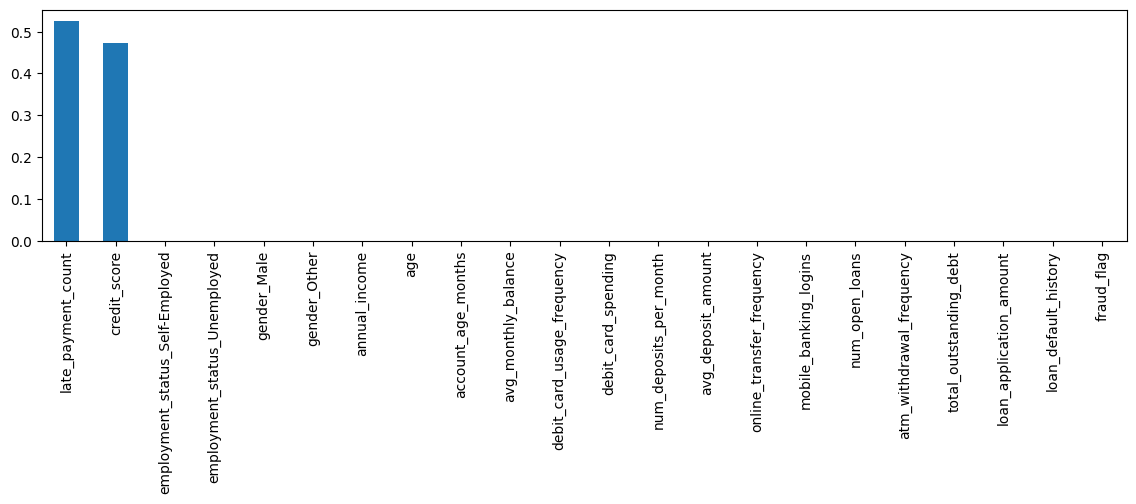

In [31]:
importances = pd.Series(model.feature_importances_, index=final_cols)
importances.sort_values(ascending=False).plot(kind='bar', figsize = (14,3))

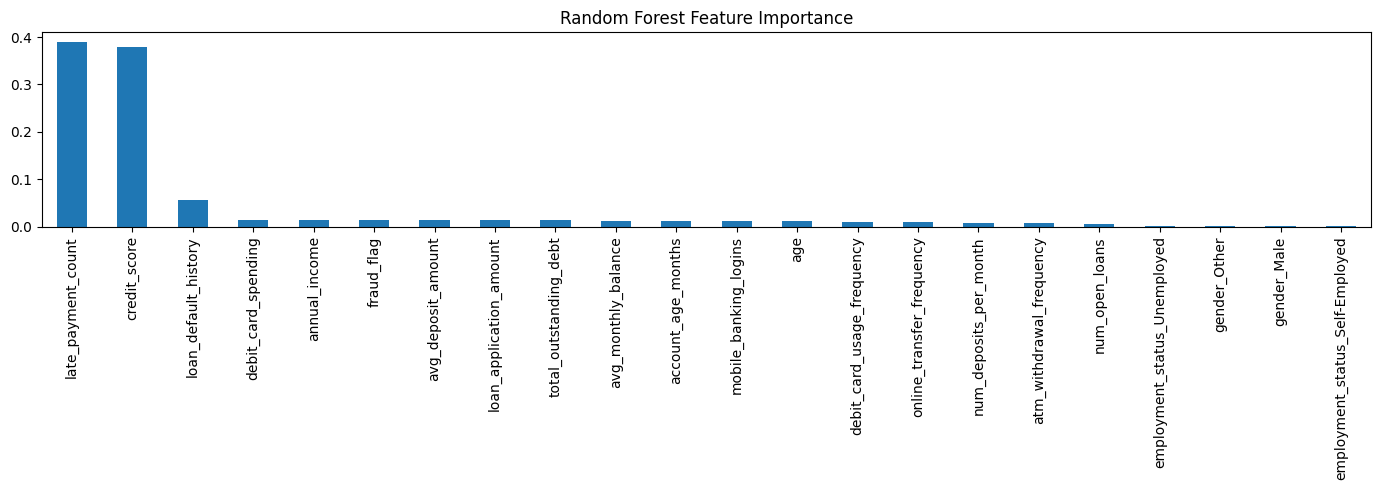

In [32]:
# Decision Tree importance can be unstable
# Random Forest averages across 100+ trees — more reliable

from sklearn.ensemble  import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).plot(kind='bar', figsize=(14,5))
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

In [33]:
rf = RandomForestClassifier(n_estimators = 100,
                            max_depth = 3,      # Control tree depth
                            min_samples_split = 6,  # Min samples to split a node
                            min_samples_leaf  = 10,  # Min samples at leaf node
                            random_state = 42,
                            class_weight = 'balanced')

rf.fit(X_train, y_train)

# predictions
y_pred_train = rf.predict(X_train)
y_pred_test = rf.predict(X_test)

print('Train Performace: ')
print(confusion_matrix(y_train, y_pred_train))
print(classification_report(y_train, y_pred_train))

print('-'*40)

print('Test Performance: ')
print(confusion_matrix(y_test, y_pred_test))
print(classification_report(y_test, y_pred_test))

Train Performace: 
[[ 937    0]
 [  35 3028]]
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       937
           1       1.00      0.99      0.99      3063

    accuracy                           0.99      4000
   macro avg       0.98      0.99      0.99      4000
weighted avg       0.99      0.99      0.99      4000

----------------------------------------
Test Performance: 
[[234   0]
 [  9 757]]
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       234
           1       1.00      0.99      0.99       766

    accuracy                           0.99      1000
   macro avg       0.98      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000



- **Grid Search Cross Validation** with Random Forest Model

In [34]:
# # Tries EVERY possible combination
# from sklearn.model_selection import GridSearchCV

# param_grid = {
#     'n_estimators'     : [50, 100, 200],
#     'max_depth'        : [3, 5, 7, 10],
#     'min_samples_split': [2, 5, 8, 10],
#     'min_samples_leaf' : [1, 3, 5, 7]
# }

# grid_search = GridSearchCV(
#     estimator  = RandomForestClassifier(class_weight='balanced', random_state=42),
#     param_grid = param_grid,
#     cv         = 5,
#     scoring    = 'f1',
#     n_jobs     = -1,    # uses all CPU cores
#     verbose    = 2
# )

# grid_search.fit(X_train, y_train)

# print('Best Parameters:', grid_search.best_params_)
# print('Best F1 Score  :', grid_search.best_score_)

In [35]:
# best_rf = grid_search.best_estimator_

# # Predictions
# y_pred_train = best_rf.predict(X_train)
# y_pred_test  = best_rf.predict(X_test)

# print(classification_report(y_train, y_pred_train))

# print(confusion_matrix(y_test, y_pred_test))
# print(classification_report(y_test, y_pred_test))

- **RandomizedSearchCV**

In [36]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators' : [50, 100, 150, 200],
    'max_depth'    : [3,5,7,10,None],
    'min_samples_split' : [2,5,8,10,15],
    'min_samples_leaf' : [1,3,5,7,10]
}

random_search = RandomizedSearchCV(
    estimator = RandomForestClassifier(class_weight = 'balanced', random_state = 42),
    param_distributions = param_dist,
    n_iter = 20,
    cv = 5,
    scoring = 'f1',
    n_jobs = -1,
    verbose = 2
)

random_search.fit(X_train, y_train)

print('Best Parameters: ', random_search.best_params_)
print('Best F1 Scores: ', random_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters:  {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_depth': None}
Best F1 Scores:  1.0


In [37]:
best_rf = random_search.best_estimator_

# Predictions
y_pred_train = best_rf.predict(X_train)
y_pred_test  = best_rf.predict(X_test)

print(classification_report(y_train, y_pred_train))

print(confusion_matrix(y_test, y_pred_test))
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       937
           1       1.00      1.00      1.00      3063

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000

[[234   0]
 [  0 766]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       234
           1       1.00      1.00      1.00       766

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



- **Gradient Boost Classifier**

In [38]:
from sklearn.ensemble import GradientBoostingClassifier

gbc = GradientBoostingClassifier(
    n_estimators      = 50,    # number of boosting stages
    learning_rate     = 0.1,    # shrinks contribution of each tree
    max_depth         = 3,      # depth of each individual tree
    min_samples_split = 8,      # min samples to split a node
    min_samples_leaf  = 5,      # min samples at leaf
    random_state      = 42
)

gbc.fit(X_train, y_train)

y_pred_train = gbc.predict(X_train)
y_pred_test  = gbc.predict(X_test)

print('Train Performance:')
print(confusion_matrix(y_train, y_pred_train))
print(classification_report(y_train, y_pred_train))

print('-'*40)

print('Test Performance:')
print(confusion_matrix(y_test, y_pred_test))
print(classification_report(y_test, y_pred_test))

Train Performance:
[[ 937    0]
 [   0 3063]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       937
           1       1.00      1.00      1.00      3063

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000

----------------------------------------
Test Performance:
[[234   0]
 [  0 766]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       234
           1       1.00      1.00      1.00       766

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



- **KNN Classifier**

In [39]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors = 8)

knn.fit(X_train, y_train)

y_pred_train = knn.predict(X_train)
y_pred_test = knn.predict(X_test)

print('Train Performance: ')
print(confusion_matrix(y_train, y_pred_train))
print(classification_report(y_train, y_pred_train))

print('-'*40)

print('Test Performance: ')
print(confusion_matrix(y_test, y_pred_test))
print(classification_report(y_test, y_pred_test))

Train Performance: 
[[ 783  154]
 [ 143 2920]]
              precision    recall  f1-score   support

           0       0.85      0.84      0.84       937
           1       0.95      0.95      0.95      3063

    accuracy                           0.93      4000
   macro avg       0.90      0.89      0.90      4000
weighted avg       0.93      0.93      0.93      4000

----------------------------------------
Test Performance: 
[[159  75]
 [ 59 707]]
              precision    recall  f1-score   support

           0       0.73      0.68      0.70       234
           1       0.90      0.92      0.91       766

    accuracy                           0.87      1000
   macro avg       0.82      0.80      0.81      1000
weighted avg       0.86      0.87      0.86      1000



Train 93% → Test 87% = 6% gap
- → Mild overfitting
- → KNN is memorizing neighborhoods
  rather than generalizing

No Risk F1 drops from 84% → 70%
- → KNN struggling with minority class
- → No class_weight parameter in KNN!

- **XG Boost Classifier**

In [40]:
from xgboost import XGBClassifier


In [41]:
# as XGBoost requires explicitly numeric dtypes...

In [42]:
X_train = X_train.astype(float)
X_test  = X_test.astype(float)

print(X_train.dtypes.unique())

[dtype('float64')]


In [43]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators      = 50,     # number of boosting rounds
    learning_rate     = 0.1,     # shrinkage — prevents overfitting
    max_depth         = 3,       # depth of each tree
    min_child_weight  = 5,       # min samples in a leaf (XGB equivalent of min_samples_leaf)
    subsample         = 0.8,     # fraction of rows per tree
    colsample_bytree  = 0.8,     # fraction of columns per tree
    gamma             = 0.1,     # min loss reduction to make a split
    scale_pos_weight  = 3,       # handles class imbalance (majority/minority ratio)
    random_state      = 42,
    eval_metric       = 'logloss'
)

xgb.fit(X_train, y_train)

y_pred_train = xgb.predict(X_train)
y_pred_test  = xgb.predict(X_test)

print('Train Performance:')
print(confusion_matrix(y_train, y_pred_train))
print(classification_report(y_train, y_pred_train))

print('-'*40)

print('Test Performance:')
print(confusion_matrix(y_test, y_pred_test))
print(classification_report(y_test, y_pred_test))

Train Performance:
[[ 934    3]
 [   0 3063]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       937
           1       1.00      1.00      1.00      3063

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000

----------------------------------------
Test Performance:
[[232   2]
 [  0 766]]
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       234
           1       1.00      1.00      1.00       766

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



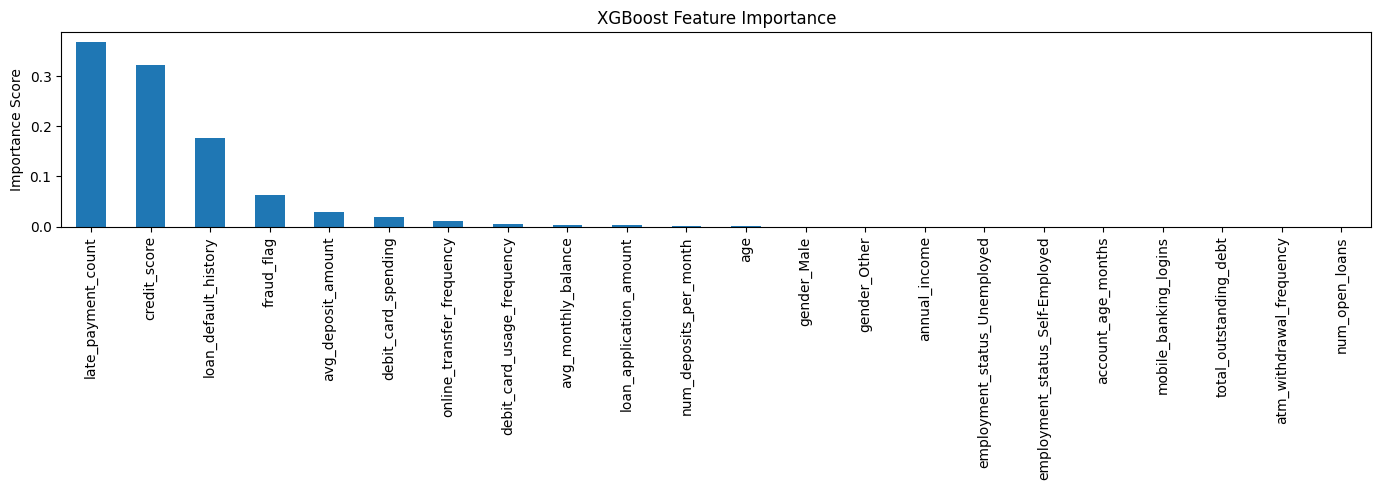

In [47]:
importances = pd.Series(xgb.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

# Plot
importances.plot(kind='bar', figsize=(14, 5))
plt.title('XGBoost Feature Importance')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()


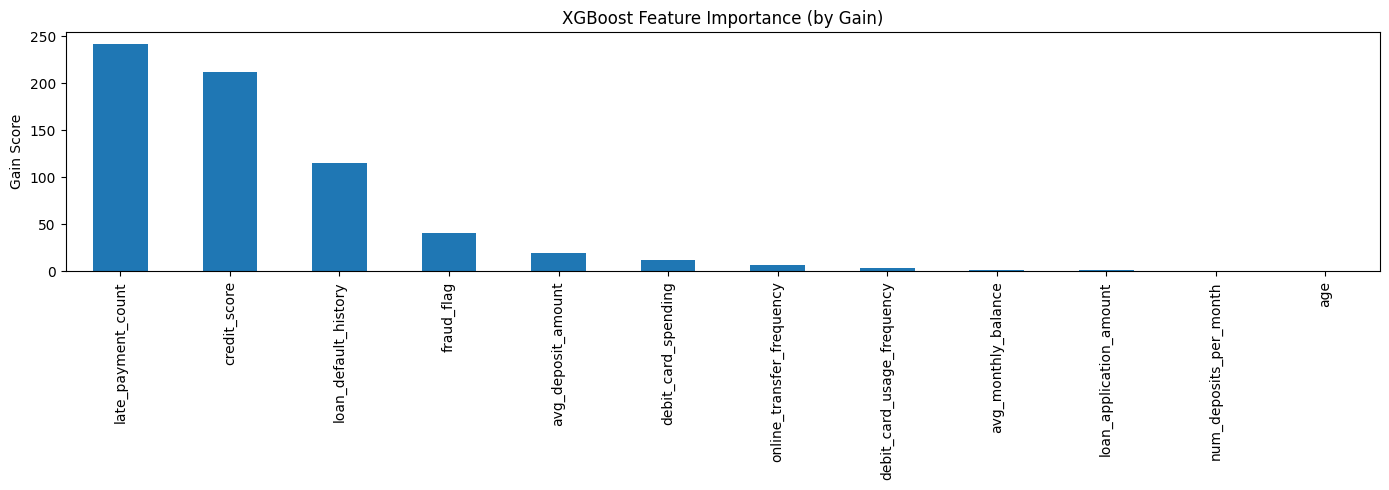

late_payment_count            242.135376
credit_score                  211.750977
loan_default_history          115.677582
fraud_flag                     41.350124
avg_deposit_amount             19.189941
debit_card_spending            12.284149
online_transfer_frequency       6.799175
debit_card_usage_frequency      3.852406
avg_monthly_balance             1.684303
loan_application_amount         1.358439
num_deposits_per_month          0.217267
age                             0.163906
dtype: float64


In [49]:
importance_gain = pd.Series(
    xgb.get_booster().get_score(importance_type='gain')
).sort_values(ascending=False)

importance_gain.plot(kind='bar', figsize=(14, 5))
plt.title('XGBoost Feature Importance (by Gain)')
plt.ylabel('Gain Score')
plt.tight_layout()
plt.show()

print(importance_gain)

Dataset exhibits very clean separable
patterns — likely synthetic in nature,
which explains perfect model performance
across all classifiers

- XGBoost's weight-based importance confirms the consistent pattern seen across all models — **late_payment_count**, **credit_score**, and **loan_default_history** are the three dominant predictors.
- However, the gain-based importance reveals a more nuanced picture — fraud_flag emerges as the 4th most valuable feature with a gain score of 40, while features like avg_deposit_amount and debit_card_spending show small but real contributions.
- The gain plot's exclusion of 10 features confirms they add no predictive value — however they are retained for business and compliance reasons as established earlier.

## Final Model Comparison Table

In [45]:
import pandas as pd

model_comparison = pd.DataFrame({
    'Model'         : ['Logistic Regression', 'KNN', 'Decision Tree',
                       'Random Forest', 'Gradient Boosting', 'XGBoost'],
    'Train Acc'     : ['90%', '93%', '99%', '100%', '100%', '100%'],
    'Test Acc'      : ['88%', '87%', '99%', '100%', '100%', '100%'],
    'False Positives': [32, 75, 0, 0, 0, 2],
    'False Negatives': [89, 59, 11, 0, 0, 0],
    'Overfitting'   : ['None', 'Mild', 'None', 'None', 'None', 'None']
})

model_comparison

,Model,Train Acc,Test Acc,False Positives,False Negatives,Overfitting
0,Logistic Regression,90%,88%,32,89,None
1,KNN,93%,87%,75,59,Mild
2,Decision Tree,99%,99%,0,11,None
3,Random Forest,100%,100%,0,0,None
4,Gradient Boosting,100%,100%,0,0,None
5,XGBoost,100%,100%,2,0,None


In [46]:
model_comparison.style.apply(
    lambda x: ['background-color: green'
               if x['Model'] == 'XGBoost'
               else '' for _ in x], axis=1
)

,Model,Train Acc,Test Acc,False Positives,False Negatives,Overfitting
0,Logistic Regression,90%,88%,32,89,None
1,KNN,93%,87%,75,59,Mild
2,Decision Tree,99%,99%,0,11,None
3,Random Forest,100%,100%,0,0,None
4,Gradient Boosting,100%,100%,0,0,None
5,XGBoost,100%,100%,2,0,None


## Saving XGBoost Model using Joblib

In [50]:
import joblib

# Saving
joblib.dump(xgb, 'xgboost_loan_risk_model.pkl')
print('Model saved successfully!')

Model saved successfully!


In [51]:
# Loading the model back
loaded_model = joblib.load('xgboost_loan_risk_model.pkl')
print('Model Loaded Successfully!')


Model Loaded Successfully!


In [53]:
# verifying the loaded model works

y_pred_verify = loaded_model.predict(X_test)
print(confusion_matrix(y_test, y_pred_verify))
print(classification_report(y_test, y_pred_verify))

[[232   2]
 [  0 766]]
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       234
           1       1.00      1.00      1.00       766

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



In [54]:
# saving ColumnTransformer

joblib.dump(ct, 'preprocessor.pkl')
print('Preprocessor Saved!')

Preprocessor Saved!
